In [8]:
import pandas as pd
import napari
import tifffile
import os
from pathlib import Path
import matplotlib.pyplot as plt
from skimage import util
import numpy as np
from skimage.filters import threshold_otsu, gaussian, threshold_isodata, threshold_minimum, threshold_triangle, threshold_otsu, threshold_mean, threshold_li, try_all_threshold, threshold_yen, threshold_multiotsu
from skimage.segmentation import clear_border, watershed, expand_labels
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import remove_small_holes, remove_small_objects, opening, disk, dilation, erosion
import contextlib
import joblib
from joblib import Parallel, delayed
from tqdm import tqdm

%matplotlib inline

@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """
    Enables parallel jobs to run and display of a tqdm progress bar.

    Parameters:
    -----------
    tqdm_object : tqdm
        The tqdm progress bar instance to be updated.

    """
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

In [2]:
label_directory = Path(r"C:\Users\isobe\The University of Manchester Dropbox\Isobel Taylor-Hearn\Bell+Marta\24wp\Basic_Initial_Output")
initial_image_directory = Path(r"C:\Users\isobe\The University of Manchester Dropbox\Isobel Taylor-Hearn\Bell+Marta\24wp\PP_NXD8_129_DIV24_24102025\Images")
label_images = [f for f in os.listdir(label_directory) if f.endswith('.tif')]
initial_images = [f for f in os.listdir(initial_image_directory) if f.endswith('.tiff')]
print(len(label_images), len(initial_images))

228 228


In [6]:
def read_clean_and_save_outputs(i, initial_image_directory, label_directory, initial_images, label_images):
    test_initial = tifffile.imread(f"{initial_image_directory}/{initial_images[i]}")
    test_label = tifffile.imread(f"{label_directory}/{label_images[i]}")
    test_label = erosion(test_label, disk(3))
    table = regionprops_table(label(test_label), properties=('label', 'area'),)
    condition = (table['area'] >= 3000)
    input_labels = table['label']
    output_labels = input_labels * condition
    output_labels = util.map_array(label(test_label), input_labels, output_labels)
    output_labels = expand_labels(output_labels, distance=3)
    fig, ax = plt.subplots(ncols=3, figsize=(15, 6))
    ax[0].imshow(test_initial, cmap='gray')

    ax[1].imshow(test_label, cmap='jet', alpha=1)
    overlay = np.ma.masked_where(output_labels == 0, output_labels)

    ax[2].imshow(test_initial, cmap='gray')
    ax[2].imshow(overlay, cmap='jet', alpha=0.5)
    titles = ["initial", "basic labels", "cleaned labels"]
    for a, title in zip(ax, titles):
        a.set_title(title)
        a.axis("off")
    plt.savefig(rf"C:\Users\isobe\The University of Manchester Dropbox\Isobel Taylor-Hearn\Bell+Marta\24wp\Basic_Initial_Output\clean_labels\cleaned_labels_{i}.png")


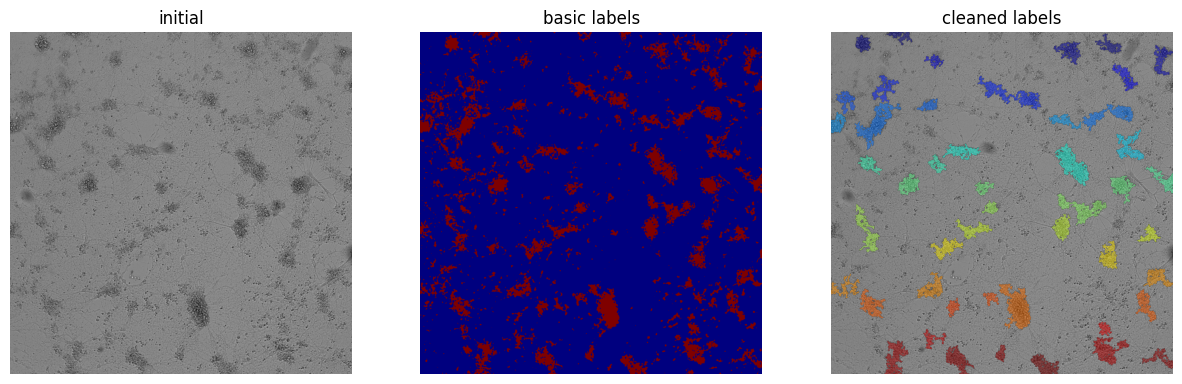

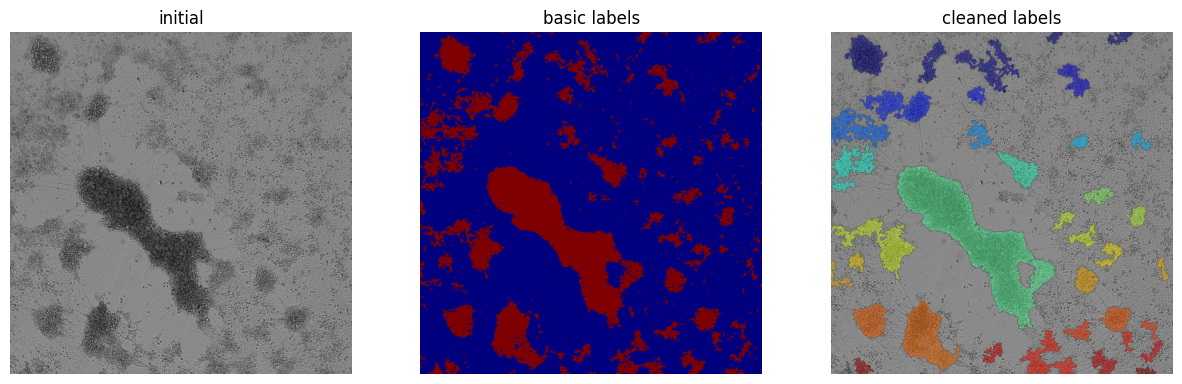

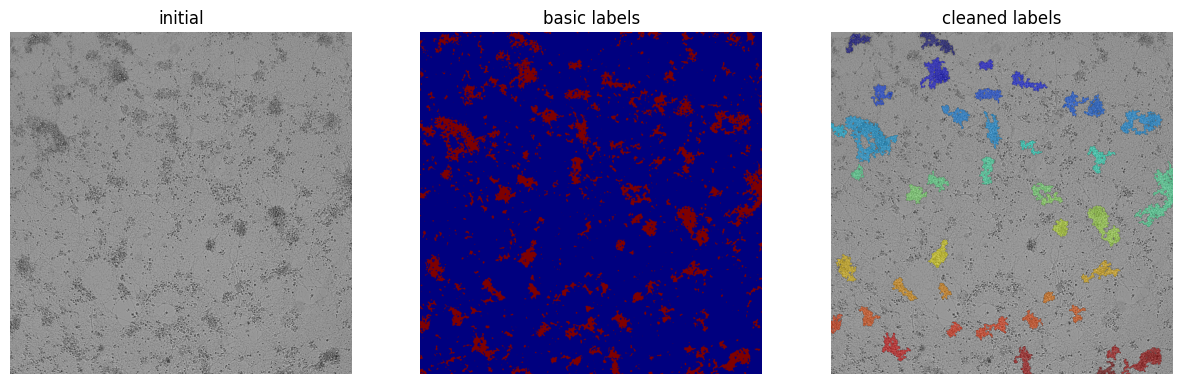

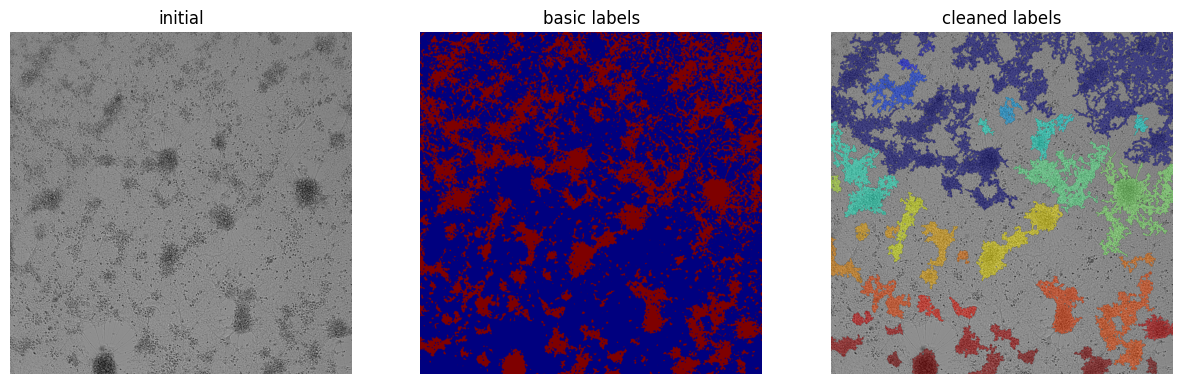

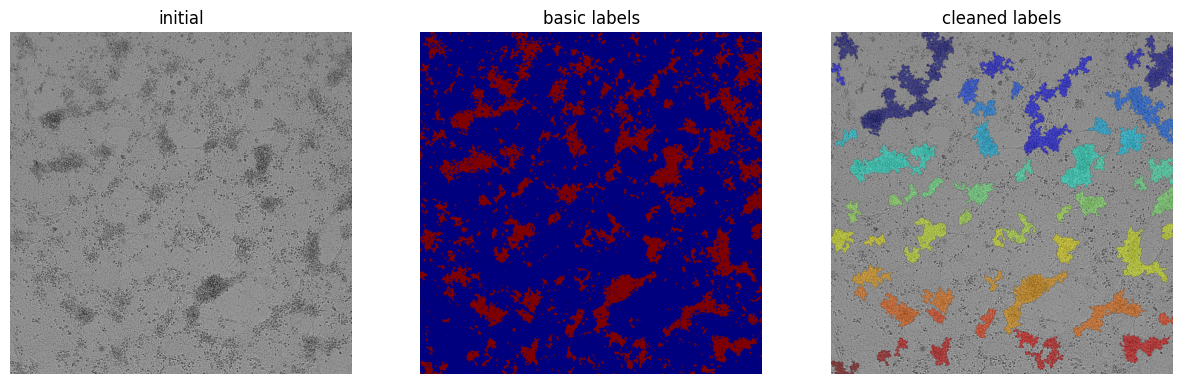

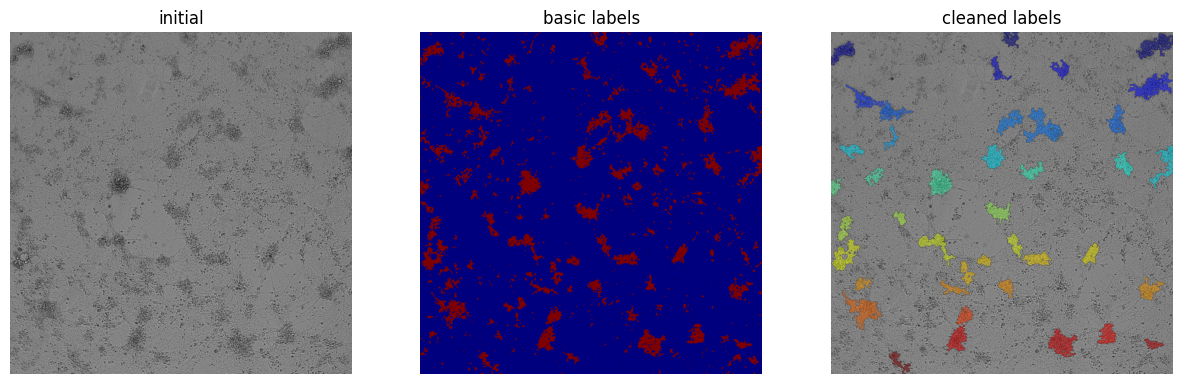

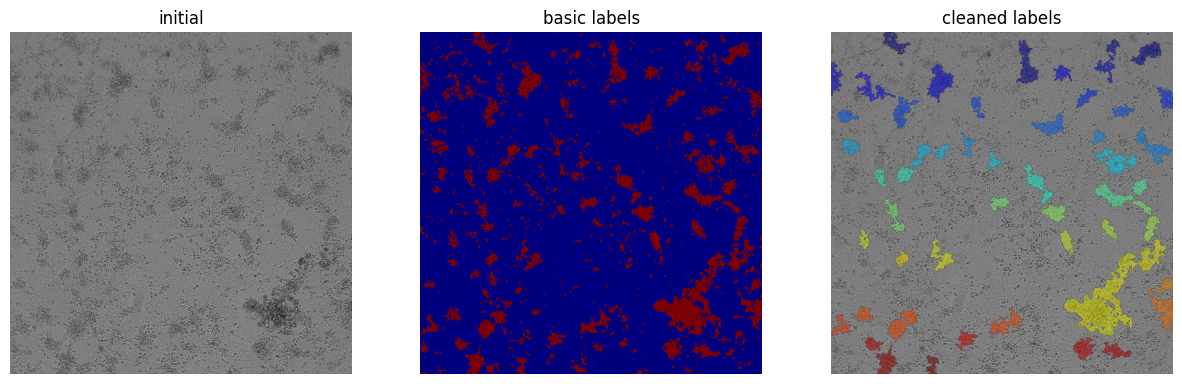

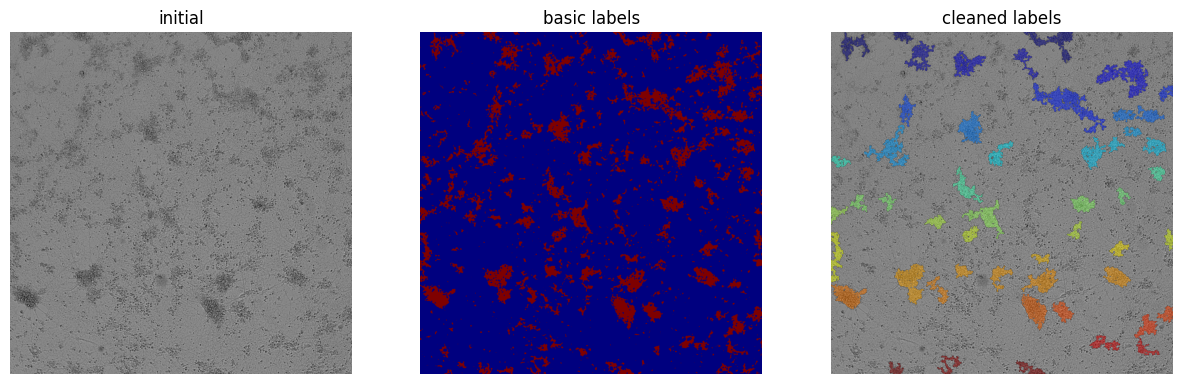

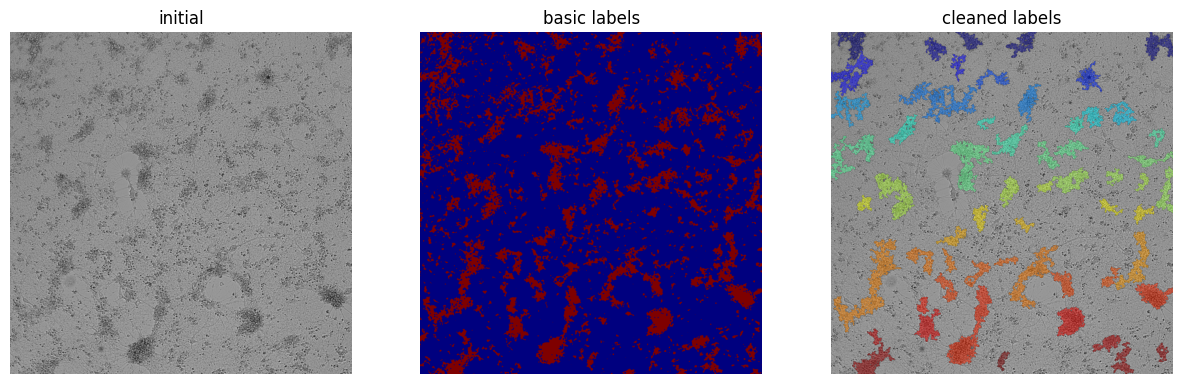

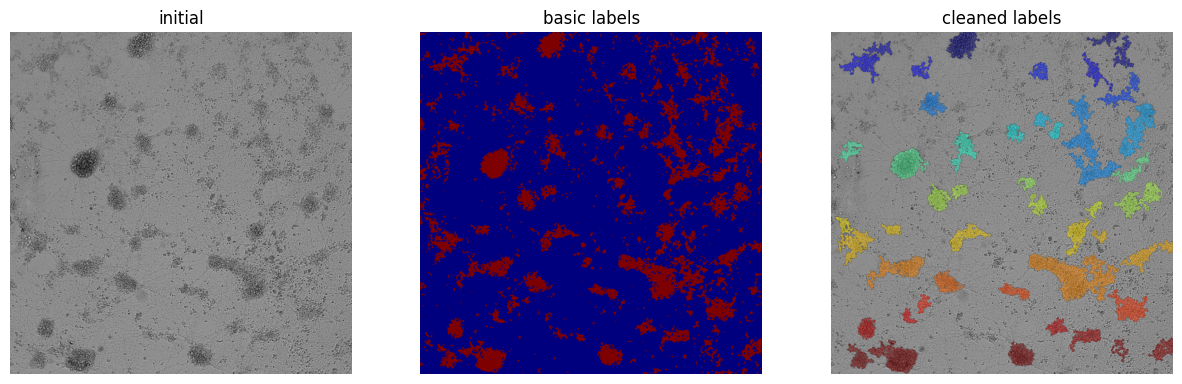

In [7]:
for i, label_image in enumerate(label_images[:10]):
    read_clean_and_save_outputs(i, initial_image_directory, label_directory, initial_images, label_images)

In [9]:
# with tqdm_joblib(tqdm(desc="Processing images", total=len(label_images))) as pbar:
#     results = Parallel(n_jobs=4, prefer="threads")(
#         delayed(read_clean_and_save_outputs)(i, initial_image_directory, label_directory, initial_images, label_images) for i in range(len(label_images))
#     )

with tqdm_joblib(tqdm(desc="Image Analysis", total=len(label_images))) as progress_bar:
    output = Parallel(n_jobs=-2)(delayed(read_clean_and_save_outputs)(i, initial_image_directory, label_directory, initial_images, label_images) for i in range(len(label_images)))

Image Analysis:  52%|█████▏    | 118/228 [01:08<01:45,  1.04it/s]c:\Users\isobe\anaconda3\envs\imaging_full\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Image Analysis: 100%|██████████| 228/228 [02:02<00:00,  1.87it/s]


In [11]:
viewer = napari.Viewer()
viewer.add_image(tifffile.imread(f"{initial_image_directory}/{initial_images[0]}"), name="Initial Image")

<Image layer 'Initial Image' at 0x2001daacb20>

c:\Users\isobe\anaconda3\envs\imaging_full\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [1]:
viewer = napari.Viewer()

NameError: name 'napari' is not defined